1.Exploratory Data Analysis

Vehicle Valuation and Depreciation Intelligence Platform

Objective

The objective of this notebook is to explore the used vehicle dataset, assess data quality, identify potential issues, and understand the relationships between vehicle characteristics and listing price before feature engineering and model development.

2. Business Questions

- Which vehicle characteristics are most strongly associated with vehicle price?
- How do mileage, age, horsepower, accident history and ownership history influence price?
- Can these characteristics be used to build a multiple linear regression model for estimating vehicle value?
- Can the model identify vehicles that appear underpriced or overpriced relative to similar vehicles?

In [92]:
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
from pathlib import Path
FIGURES_DIR = Path("../reports/figures/Eda_plots")
df = pd.read_csv("../data/processed/used_cars_reduced.csv")
pd.set_option("display.float_format", "{:,.2f}".format)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

C:\Users\casey\AppData\Local\Temp\ipykernel_25208\650562487.py:6: DtypeWarning: Columns (0: dealer_zip) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/used_cars_reduced.csv")


In [93]:
df


,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,...,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,vehicle_damage_category,wheel_system,year
0,Bayamon,960,I4,I4,NaN,Gasoline,NaN,177.00,True,Jeep,...,Renegade,NaN,"23,141.00",NaN,2.80,A,Latitude FWD,NaN,FWD,2019
1,San Juan,922,I4,I4,NaN,Gasoline,NaN,246.00,True,Land Rover,...,Discovery Sport,NaN,"46,500.00",NaN,3.00,A,S AWD,NaN,AWD,2020
2,Guaynabo,969,H4,H4,False,Gasoline,False,305.00,False,Subaru,...,WRX STI,3.00,"46,995.00",False,NaN,M,Base,NaN,AWD,2016
3,San Juan,922,V6,V6,NaN,Gasoline,NaN,340.00,True,Land Rover,...,Discovery,NaN,"67,430.00",NaN,3.00,A,V6 HSE AWD,NaN,AWD,2020
4,San Juan,922,I4,I4,NaN,Gasoline,NaN,246.00,True,Land Rover,...,Discovery Sport,NaN,"48,880.00",NaN,3.00,A,S AWD,NaN,AWD,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663246,Fairfield,94533,I4,I4,False,Gasoline,False,170.00,False,Chevrolet,...,Equinox,1.00,"17,998.00",False,4.27,A,1.5T LT FWD,NaN,FWD,2018
2663247,Vallejo,94591,V6,V6,NaN,Gasoline,NaN,310.00,True,Chevrolet,...,Traverse,NaN,"36,490.00",NaN,4.53,A,LS FWD,NaN,FWD,2020
2663248,Napa,94559,NaN,NaN,False,NaN,True,240.00,False,Ford,...,Fusion,2.00,"12,990.00",False,4.14,A,SE,NaN,FWD,2016
2663249,Fairfield,94533,I4 Diesel,I4 Diesel,False,Diesel,False,180.00,False,Jaguar,...,XE,1.00,"26,998.00",False,4.27,A,20d Premium AWD,NaN,AWD,2017


3. Initial inspections

In [94]:
df.shape

(2663251, 21)

In [95]:
df.head()

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,...,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,vehicle_damage_category,wheel_system,year
0,Bayamon,960,I4,I4,NaN,Gasoline,NaN,177.00,True,Jeep,...,Renegade,NaN,"23,141.00",NaN,2.80,A,Latitude FWD,NaN,FWD,2019
1,San Juan,922,I4,I4,NaN,Gasoline,NaN,246.00,True,Land Rover,...,Discovery Sport,NaN,"46,500.00",NaN,3.00,A,S AWD,NaN,AWD,2020
2,Guaynabo,969,H4,H4,False,Gasoline,False,305.00,False,Subaru,...,WRX STI,3.00,"46,995.00",False,NaN,M,Base,NaN,AWD,2016
3,San Juan,922,V6,V6,NaN,Gasoline,NaN,340.00,True,Land Rover,...,Discovery,NaN,"67,430.00",NaN,3.00,A,V6 HSE AWD,NaN,AWD,2020
4,San Juan,922,I4,I4,NaN,Gasoline,NaN,246.00,True,Land Rover,...,Discovery Sport,NaN,"48,880.00",NaN,3.00,A,S AWD,NaN,AWD,2020


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2663251 entries, 0 to 2663250
Data columns (total 20 columns):
 #   Column            Dtype  
---  ------            -----  
 0   city              str    
 1   dealer_zip        object 
 2   engine_cylinders  str    
 3   engine_type       str    
 4   frame_damaged     object 
 5   fuel_type         str    
 6   has_accidents     object 
 7   horsepower        float64
 8   is_new            bool   
 9   make_name         str    
 10  mileage           float64
 11  model_name        str    
 12  owner_count       float64
 13  price             float64
 14  salvage           object 
 15  seller_rating     float64
 16  transmission      str    
 17  trim_name         str    
 18  wheel_system      str    
 19  year              int64  
dtypes: bool(1), float64(5), int64(1), object(4), str(9)
memory usage: 388.6+ MB


In [127]:
df.tail()


,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
2663246,Fairfield,94533,I4,I4,False,Gasoline,False,170.00,False,Chevrolet,"41,897.00",Equinox,1.00,"17,998.00",False,4.27,A,1.5T LT FWD,FWD,2018
2663247,Vallejo,94591,V6,V6,NaN,Gasoline,NaN,310.00,True,Chevrolet,5.00,Traverse,NaN,"36,490.00",NaN,4.53,A,LS FWD,FWD,2020
2663248,Napa,94559,NaN,NaN,False,NaN,True,240.00,False,Ford,"57,992.00",Fusion,2.00,"12,990.00",False,4.14,A,SE,FWD,2016
2663249,Fairfield,94533,I4 Diesel,I4 Diesel,False,Diesel,False,180.00,False,Jaguar,"27,857.00",XE,1.00,"26,998.00",False,4.27,A,20d Premium AWD,AWD,2017
2663250,Napa,94559,I4,I4,False,Gasoline,False,170.00,False,Nissan,"22,600.00",Rogue,1.00,"19,900.00",False,4.33,A,2017.5 SV FWD,FWD,2017


In [98]:
df.dtypes

city                           str
dealer_zip                  object
engine_cylinders               str
engine_type                    str
frame_damaged               object
fuel_type                      str
has_accidents               object
horsepower                 float64
is_new                        bool
make_name                      str
mileage                    float64
model_name                     str
owner_count                float64
price                      float64
salvage                     object
seller_rating              float64
transmission                   str
trim_name                      str
vehicle_damage_category    float64
wheel_system                   str
year                         int64
dtype: object

In [99]:
df.columns

Index(['city', 'dealer_zip', 'engine_cylinders', 'engine_type',
       'frame_damaged', 'fuel_type', 'has_accidents', 'horsepower', 'is_new',
       'make_name', 'mileage', 'model_name', 'owner_count', 'price', 'salvage',
       'seller_rating', 'transmission', 'trim_name', 'vehicle_damage_category',
       'wheel_system', 'year'],
      dtype='str')

In [100]:
df.describe()

,horsepower,mileage,owner_count,price,seller_rating,vehicle_damage_category,year
count,"2,512,660.00","2,560,735.00","1,482,094.00","2,663,251.00","2,624,951.00",0.00,"2,663,251.00"
mean,251.67,"34,730.86",1.53,"29,724.89",4.28,NaN,"2,017.43"
std,91.03,"77,967.58",0.92,"20,251.10",0.51,NaN,4.34
min,55.00,0.00,1.00,165.00,1.00,NaN,"1,915.00"
25%,176.00,9.00,1.00,"17,681.00",4.03,NaN,"2,017.00"
50%,248.00,"17,880.00",1.00,"26,000.00",4.35,NaN,"2,019.00"
75%,305.00,"49,241.00",2.00,"38,290.00",4.62,NaN,"2,020.00"
max,"1,001.00","99,999,988.00",19.00,"3,299,995.00",5.00,NaN,"2,021.00"


In [101]:
df.drop("vehicle_damage_category", axis=1, inplace=True)

4.Categorizing Columns

In [102]:
numerical_data = df.select_dtypes(include=["number"]).columns.tolist()
categorical_data = df.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

Initial Data Quality Findings and add:

1.Duplicate records were identified and were removed before modelling. 
2. Remove vehicle_damage_category (100% missing).
3.Investigate or treat implausible mileage values (>1,000,000).
4.Investigate missing values in frame_damaged, has_accidents, salvage, and owner_count.
5.Does dealer_zip add meaningful information beyond city, or is it mostly redundant?
are engine cylinder matching engine-type?
6.Later, during feature engineering, ill group infrequent trims because thousands of unique categories can be difficult for a simple linear regression model.
7.engine_cylinders contains identical information to engine_type and will be removed during feature engineering.
8.

In [103]:
df[numerical_data].describe()

,horsepower,mileage,owner_count,price,seller_rating,year
count,"2,512,660.00","2,560,735.00","1,482,094.00","2,663,251.00","2,624,951.00","2,663,251.00"
mean,251.67,"34,730.86",1.53,"29,724.89",4.28,"2,017.43"
std,91.03,"77,967.58",0.92,"20,251.10",0.51,4.34
min,55.00,0.00,1.00,165.00,1.00,"1,915.00"
25%,176.00,9.00,1.00,"17,681.00",4.03,"2,017.00"
50%,248.00,"17,880.00",1.00,"26,000.00",4.35,"2,019.00"
75%,305.00,"49,241.00",2.00,"38,290.00",4.62,"2,020.00"
max,"1,001.00","99,999,988.00",19.00,"3,299,995.00",5.00,"2,021.00"


In [104]:
df[df["mileage"] == df["mileage"].max()]

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
2242507,Houston,77065,I6 Diesel,I6 Diesel,NaN,Diesel,NaN,NaN,True,RAM,"99,999,988.00",3500 Chassis,NaN,"52,610.00",NaN,3.57,A,NaN,NaN,2019


In [105]:
#Several extremely large mileage values (e.g., 1,111,111 and 99,999,988) appear to be placeholder or #
#erroneous values rather than genuine odometer readings. 
#Further investigation or consultation of the dataset documentation is recommended before deciding how to treat these records.
df[df["mileage"] > 1_000_000]

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
185063,Nappanee,46550,V8,V8,NaN,Gasoline,NaN,355.00,True,Chevrolet,"4,290,461.00",Silverado 1500,NaN,"50,775.00",NaN,5.00,A,LT Crew Cab 4WD,4WD,2020
1180953,Belleview,34420,V6,V6,NaN,Gasoline,NaN,375.00,True,Ford,"1,225,238.00",F-150,NaN,"45,149.00",NaN,4.50,A,XLT SuperCrew RWD,4X2,2020
1853005,Boise,83713,V8,V8,NaN,Gasoline,NaN,355.00,True,Chevrolet,"1,111,111.00",Silverado 1500,NaN,"39,523.00",NaN,3.82,A,LT Double Cab 4WD,4WD,2020
1853098,Boise,83713,I4,I4,NaN,Gasoline,NaN,170.00,True,Chevrolet,"1,111,111.00",Equinox,NaN,"23,620.00",NaN,3.82,A,1.5T LT AWD,4WD,2020
1853986,Boise,83713,V8,V8,NaN,Gasoline,NaN,355.00,True,Chevrolet,"1,111,111.00",Silverado 1500,NaN,"41,420.00",NaN,3.82,A,LT Double Cab 4WD,4WD,2020
1855598,Boise,83713,I4,I4,NaN,Gasoline,NaN,237.00,True,Cadillac,"1,111,111.00",XT5,NaN,"45,970.00",NaN,3.82,A,Luxury AWD,4WD,2020
2242507,Houston,77065,I6 Diesel,I6 Diesel,NaN,Diesel,NaN,NaN,True,RAM,"99,999,988.00",3500 Chassis,NaN,"52,610.00",NaN,3.57,A,NaN,NaN,2019


Seven records contain implausibly large mileage values (>1,000,000). Several share identical values (e.g., 1,111,111), suggesting placeholder or erroneous entries rather than genuine odometer readings. These records will require special treatment during data cleaning.

5. Owner Count Investigation

In [106]:
df[df["owner_count"]  > 10]

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
39261,Lodi,7644,V8,V8,False,Gasoline,False,170.00,False,Cadillac,"104,655.00",Brougham,12.00,"3,995.00",False,3.89,A,RWD,RWD,1991
50831,Bloomfield,7003,V8,V8,False,Gasoline,False,300.00,False,Ford,"203,000.00",F-150,11.00,"7,999.00",False,4.56,A,FX4 Ext. Cab SB 4WD,4WD,2004
67287,Macomb,48042,V8,V8,False,Gasoline,False,180.00,False,Chevrolet,"46,965.00",Monte Carlo,15.00,"24,990.00",False,4.76,A,SS RWD,RWD,1987
94271,Somerville,2143,I5,I5,False,Gasoline,False,168.00,False,Volvo,"193,131.00",S40,11.00,"3,995.00",False,4.45,M,2.4i,FWD,2005
172760,Warsaw,46582,I4,I4,False,Gasoline,False,115.00,False,Volkswagen,"157,225.00",Beetle,11.00,"4,999.00",False,4.62,NaN,2 Dr GLS Hatchback,FWD,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535149,Spring Valley,91977,I6,I6,False,Gasoline,False,181.00,False,Jeep,"109,000.00",Wrangler,11.00,"12,995.00",False,5.00,A,Sport,4WD,1998
2552437,Canoga Park,91303,I4,I4,False,Gasoline,True,115.00,False,Honda,"202,356.00",Civic Coupe,11.00,"1,999.00",False,4.00,A,LX,FWD,2001
2623307,Sunnyvale,94085,I4,I4,False,Gasoline,False,122.00,False,Nissan,"102,700.00",Versa,11.00,"5,500.00",False,NaN,A,S 1.8,FWD,2009
2632136,Santa Clara,95051,I4,I4,False,Gasoline,False,126.00,False,Jeep,"143,112.00",Wrangler,11.00,"8,999.00",False,4.50,M,S,4WD,1991


Owner count exhibits a negative association with vehicle price and a positive association with mileage. Vehicles with more previous owners also tend to be older, suggesting that owner count is correlated with both vehicle age and usage. The feature appears informative and will be retained for model training, while recognizing that its effect may overlap with other predictors such as year and mileage.

In [107]:
df["owner_count"].value_counts().sort_index()

owner_count
1.00     972156
2.00     330478
3.00     116768
4.00      39764
5.00      14207
6.00       5286
7.00       1977
8.00        836
9.00        366
10.00       128
11.00        73
12.00        21
13.00        16
14.00         7
15.00         6
16.00         3
18.00         1
19.00         1
Name: count, dtype: int64

In [108]:
df["owner_count"].isna().sum()

np.int64(1181157)

In [109]:
df[df["owner_count"] == 19]

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
859385,Mt Sterling,40353,V8,V8,False,Gasoline,True,220.00,False,Dodge,"126,611.00",RAM 1500,19.00,"3,694.00",False,4.22,A,LT 4WD,4WD,1997


In [110]:
df.groupby("owner_count")["price"].mean()

owner_count
1.00    25,225.62
2.00    17,941.32
3.00    14,317.36
4.00    12,710.21
5.00    12,016.20
6.00    12,050.94
7.00    13,296.37
8.00    11,726.27
9.00    13,394.89
10.00   10,739.07
11.00   10,024.23
12.00    5,798.00
13.00    7,630.50
14.00   12,681.43
15.00   10,176.50
16.00   10,774.67
18.00    6,999.00
19.00    3,694.00
Name: price, dtype: float64

In [111]:
df.groupby("owner_count")["mileage"].mean()

owner_count
1.00     41,882.28
2.00     81,649.54
3.00    105,846.50
4.00    121,851.00
5.00    132,584.19
6.00    139,110.61
7.00    141,454.55
8.00    144,748.62
9.00    151,364.29
10.00   146,067.66
11.00   156,307.33
12.00   155,633.69
13.00   196,052.38
14.00   119,815.17
15.00   180,124.60
16.00   244,811.67
18.00   211,192.00
19.00   126,611.00
Name: mileage, dtype: float64

In [112]:
df.groupby("owner_count")["year"].mean()

owner_count
1.00    2,017.07
2.00    2,013.85
3.00    2,011.30
4.00    2,009.16
5.00    2,007.19
6.00    2,005.50
7.00    2,003.96
8.00    2,002.79
9.00    2,001.91
10.00   2,000.38
11.00   1,999.11
12.00   1,998.38
13.00   1,997.19
14.00   1,994.00
15.00   1,995.50
16.00   1,994.67
18.00   1,995.00
19.00   1,997.00
Name: year, dtype: float64

6. Correlation Analysis

In [113]:
#Horsepower exhibits the strongest positive linear relationship with price, while mileage and owner count show negative relationships.
# These variables are likely to be informative predictors during model training.
df[numerical_data].corr()


,horsepower,mileage,owner_count,price,seller_rating,year
horsepower,1.00,-0.05,0.00,0.60,0.05,0.06
mileage,-0.05,1.00,0.52,-0.28,0.01,-0.46
owner_count,0.00,0.52,1.00,-0.23,0.01,-0.59
price,0.60,-0.28,-0.23,1.00,0.06,0.37
seller_rating,0.05,0.01,0.01,0.06,1.00,-0.04
year,0.06,-0.46,-0.59,0.37,-0.04,1.00


In [114]:
df[numerical_data].skew()

horsepower        0.67
mileage         823.52
owner_count       2.47
price            14.78
seller_rating    -1.54
year             -4.43
dtype: float64

In [115]:
df[categorical_data].describe()

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,is_new,make_name,model_name,salvage,transmission,trim_name,wheel_system
count,2663251,2663251,2575334,2575334,1567074,2590613,1567074,2663251,2663251,2663251,1567074,2608238,2560249,2535217
unique,4687,10411,39,39,2,8,2,2,100,1429,2,4,9062,5
top,Houston,77477,I4,I4,False,Gasoline,False,False,Ford,F-150,False,A,SE FWD,FWD
freq,37446,7058,1216031,1216031,1552123,2297701,1324168,1527324,442252,119058,1556555,2193284,72751,1082600


engine_type and engine_cylinders contain identical information, including matching missing values (.equals() returned True). Therefore, engine_cylinders is redundant and can be removed during feature engineering to eliminate duplicate information.

7. Redundant Feature Investigation

In [116]:
(df["engine_type"] == df["engine_cylinders"]).all()

np.False_

In [117]:
df[df["engine_type"] != df["engine_cylinders"]]

,city,dealer_zip,engine_cylinders,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,transmission,trim_name,wheel_system,year
42,Bronx,10466,NaN,NaN,False,NaN,False,180.00,False,Jeep,"15,778.00",Renegade,1.00,"16,200.00",False,2.80,A,Altitude 4WD,4WD,2017
50,Bronx,10466,NaN,NaN,False,NaN,False,NaN,False,Subaru,"19,801.00",Impreza,1.00,"17,300.00",False,2.80,CVT,2.0i Touring Wagon AWD,NaN,2018
61,Bronx,10466,NaN,NaN,False,NaN,False,283.00,False,Chrysler,"57,995.00",200,3.00,"6,500.00",False,2.80,A,Touring Sedan FWD,FWD,2013
112,Bronx,10466,NaN,NaN,False,NaN,False,360.00,False,Jeep,"42,942.00",Grand Cherokee,1.00,"33,700.00",False,2.80,A,Trailhawk 4WD,4WD,2019
215,Bronx,10466,NaN,NaN,False,NaN,False,395.00,False,RAM,"38,602.00",1500,2.00,"48,700.00",False,2.80,A,Laramie Longhorn Crew Cab 4WD,4WD,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663086,Fairfield,94533,NaN,NaN,False,Electric,False,NaN,False,Chevrolet,"31,540.00",Bolt EV,1.00,"17,998.00",False,4.27,A,Premier FWD,FWD,2017
2663094,Ukiah,95482,NaN,NaN,False,Electric,True,NaN,False,Chevrolet,"33,921.00",Bolt EV,1.00,"19,479.00",False,4.53,A,Premier FWD,FWD,2017
2663131,Fairfield,94533,NaN,NaN,False,Electric,False,NaN,False,Nissan,"14,247.00",LEAF,1.00,"9,599.00",False,4.27,A,S,FWD,2016
2663161,Fairfield,94533,NaN,NaN,False,Electric,False,NaN,False,Nissan,"15,588.00",LEAF,1.00,"9,599.00",False,4.27,A,S,FWD,2016


In [118]:
df["engine_type"].equals (df["engine_cylinders"])

True

In [119]:
df['salvage']

0            NaN
1            NaN
2          False
3            NaN
4            NaN
           ...  
2663246    False
2663247      NaN
2663248    False
2663249    False
2663250    False
Name: salvage, Length: 2663251, dtype: object

In [120]:
df["salvage"].value_counts(dropna=False)

salvage
False    1556555
NaN      1096177
True       10519
Name: count, dtype: int64

In [121]:
df.groupby("salvage")["price"].mean()

salvage
False   23,215.90
True    13,737.68
Name: price, dtype: float64

In [122]:
df.groupby("has_accidents")["price"].mean()

has_accidents
False   24,300.46
True    16,893.12
Name: price, dtype: float64

In [123]:
df["has_accidents"].value_counts(dropna=False)

has_accidents
False    1324168
NaN      1096177
True      242906
Name: count, dtype: int64

9. Exploratory Data Analysis Summary

 Key Findings

- Duplicate records were removed.
- vehicle_damage_category contains only missing values.
- engine_type and engine_cylinders are redundant.
- Mileage contains several implausible values requiring treatment.
- Horsepower shows the strongest positive relationship with price.
- Mileage and owner count are negatively associated with price.
- Salvage vehicles and vehicles with accident histories tend to have lower prices.

 Implications for Feature Engineering

- Remove redundant features.
- Handle missing values.
- Address implausible mileage observations.
- Encode categorical variables.
- Prepare numerical variables for multiple linear regression.

PLOT VISUALISATIONS

In [124]:
numerical_data


['horsepower', 'mileage', 'owner_count', 'price', 'seller_rating', 'year']

In [125]:
numerical_data.remove('index')

ValueError: list.remove(x): x not in list

In [ ]:
numerical_data

['horsepower', 'mileage', 'owner_count', 'price', 'seller_rating', 'year']

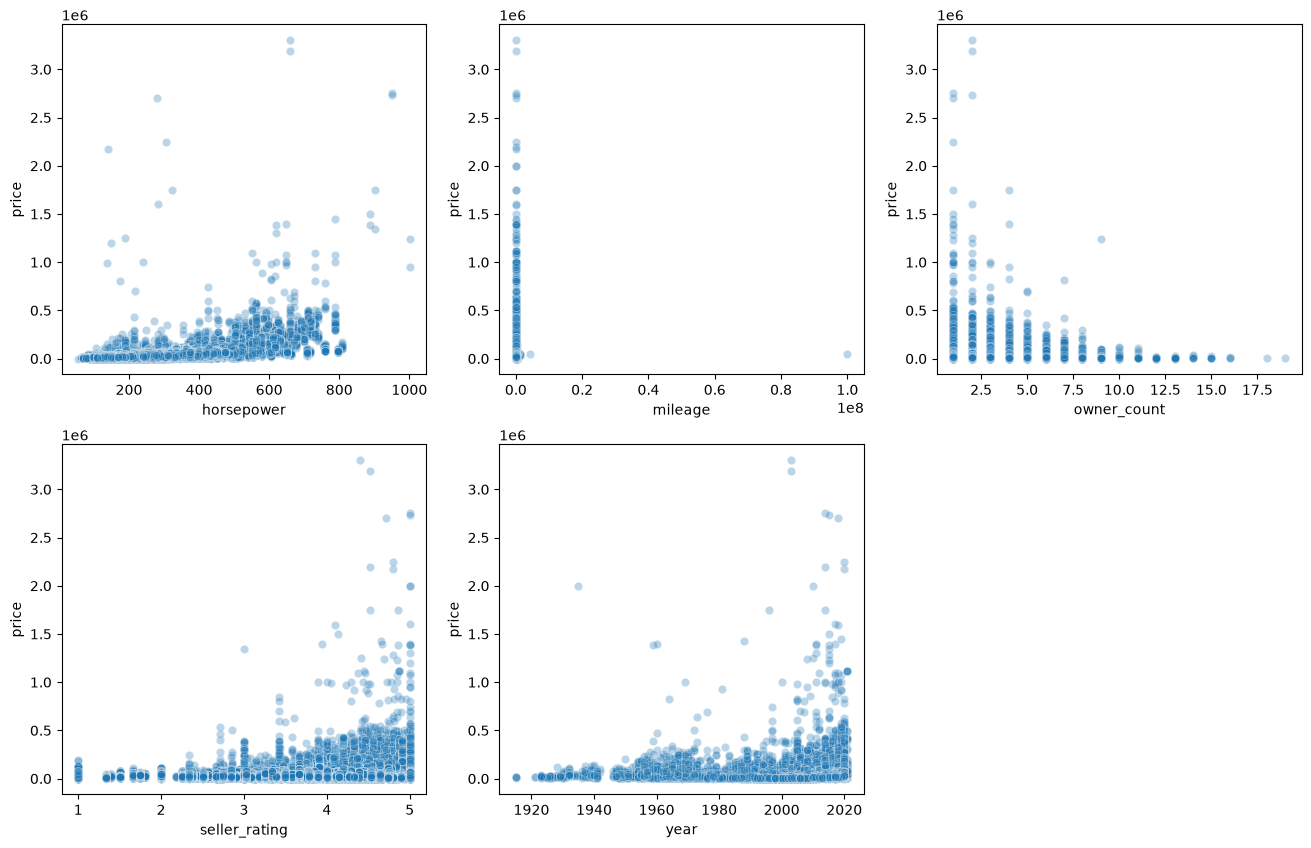

In [ ]:
features = [col for col in numerical_data if col != "price"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        data=df,
        x=feature,
        y="price",
        alpha=0.3,
        ax=axes[i]
    )
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])
    axes[i].set_title(f"Price vs {feature.replace('_', ' ').title()}")

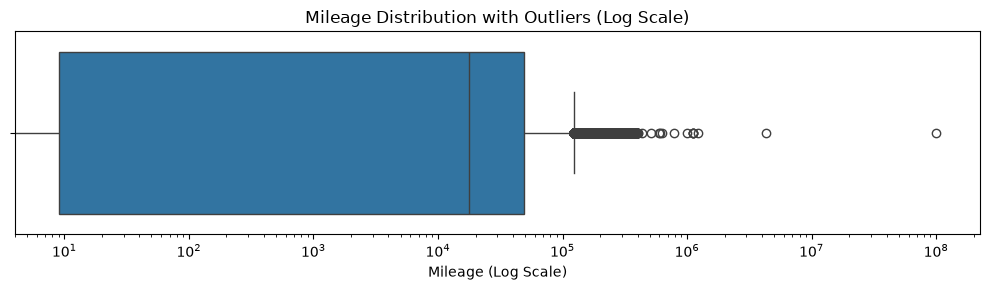

In [ ]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="mileage"
)

plt.xscale("log")

plt.title("Mileage Distribution with Outliers (Log Scale)")
plt.xlabel("Mileage (Log Scale)")

plt.tight_layout()
plt.savefig("../reports/figures/Eda_plots/mileage_boxplot.png")
plt.show()

Relationship Between Numerical Features and Vehicle Price As well as Mileage Distribution with Outliers

Vehicle price increases with newer model years.
Higher horsepower generally corresponds to higher prices.
Higher mileage is associated with lower prices.
Vehicles with more previous owners tend to be cheaper.
Mileage contains significant outliers that require cleaning before modeling.

The box plot reveals several extreme mileage observations. Most vehicles have mileage within a relatively narrow range, while a small number of records contain exceptionally large values (including implausible values exceeding one million miles). These observations warrant further investigation before model training.


In [ ]:
df.columns



Index(['index', 'city', 'dealer_zip', 'engine_cylinders', 'engine_type',
       'frame_damaged', 'fuel_type', 'has_accidents', 'horsepower', 'is_new',
       'make_name', 'mileage', 'model_name', 'owner_count', 'price', 'salvage',
       'seller_rating', 'transmission', 'trim_name', 'wheel_system', 'year'],
      dtype='str')